In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid, trapezoid

Rotation Measure = 2.31 rad/m^2


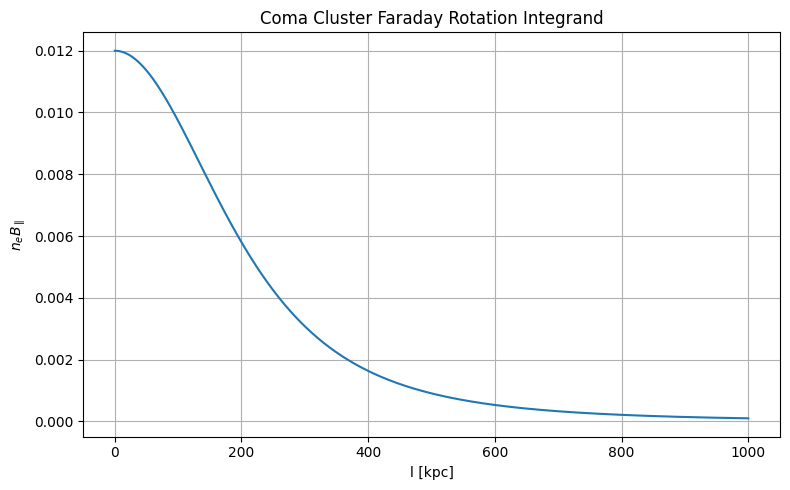

In [6]:
#coma cluster parameters-

n0 = 3e-3        # central electron density [cm^-3]
B0 = 4.0         # central magnetic field [microGauss]

rc = 291.0       # core radius [kpc]
beta = 0.75
eta = 0.67

L = 1000         # integration limit is 1 Mpc[1000 ckpc]

# Line-of-sight coordinate
l = np.linspace(0, L, 5000)


# Electron density profile (beta-model)

ne = n0 * (1 + (l/rc)**2)**(-3*beta/2)


# Magnetic field scaling 
B = B0 * (ne/n0)**eta

# RM 

integrand = ne * B

RM = 0.812* trapezoid(integrand, l)
#0.812 comes from the constant factor = e^3/ 2*pi*me^2*c^4

print(f"Rotation Measure = {RM:.2f} rad/m^2")

# RM_cumulative = 0.812 * cumulative_trapezoid(
#     integrand,
#     l,
#     initial=0
# )

# Plot-

plt.figure(figsize=(8,5))

plt.plot(l, integrand)

plt.xlabel("l [kpc]")
plt.ylabel(r"$n_e B_{\parallel}$")
plt.title("Coma Cluster Faraday Rotation Integrand")

plt.grid(True)
plt.tight_layout()

plt.show()


Total Line-of-Sight RM = -0.74 rad/m^2


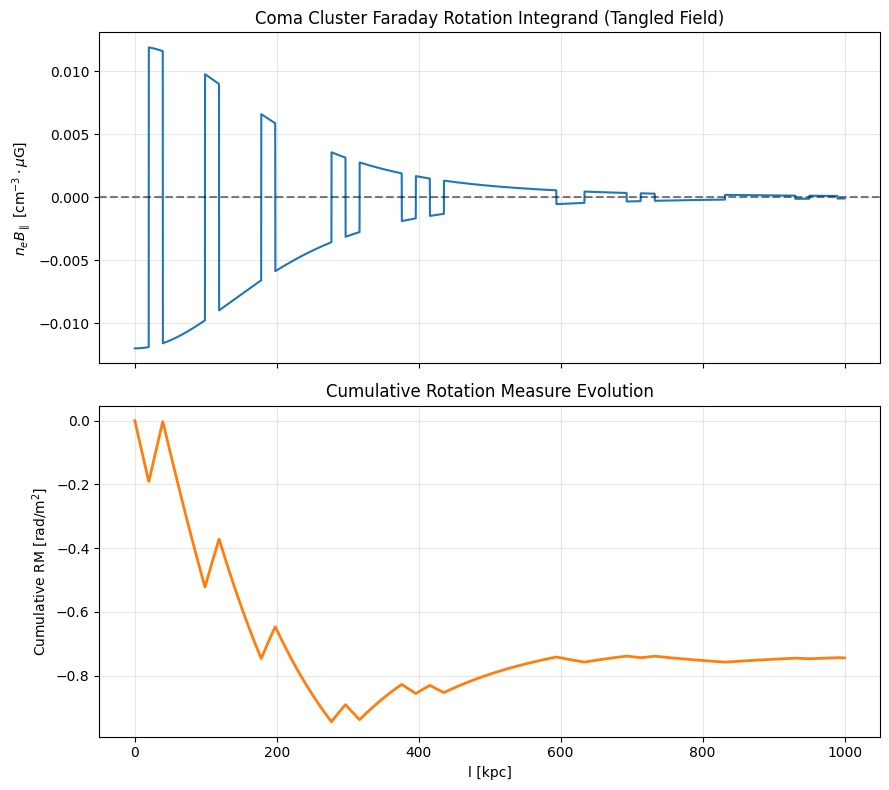

In [5]:
import numpy as np
from scipy.integrate import trapezoid, cumulative_trapezoid
import matplotlib.pyplot as plt

# 1. Physical Cluster Parameters
n0 = 3e-3        # central electron density [cm^-3]
B0 = 4.0         # central magnetic field [microGauss]
rc = 291.0       # core radius [kpc]
beta = 0.75
eta = 0.67

L = 1000         # 1 Mpc integration limit [kpc]
steps = 5000
l = np.linspace(0, L, steps)
dl = l[1] - l[0] # Step size in kpc

# 2. Compute Profiles
ne = n0 * (1 + (l/rc)**2)**(-3*beta/2)
B_amplitude = B0 * (ne/n0)**eta

# 3. Simulate Tangled Line-of-Sight Magnetic Field (B_parallel)
# We assume the field switches direction randomly every ~20 kpc
np.random.seed(42) # For reproducible random fields
coherence_scale = 20.0 # kpc
cells_per_scale = int(coherence_scale / dl)

# Generate random signs (+1 or -1) for each magnetic domain
num_cells = int(np.ceil(steps / cells_per_scale))
random_signs = np.random.choice([-1, 1], size=num_cells)
B_sign = np.repeat(random_signs, cells_per_scale)[:steps]

# Final parallel field vector component
B_parallel = B_amplitude * B_sign

# 4. Integrate Rotation Measure
integrand = ne * B_parallel

# Total RM using correct kpc scale factor
RM_total = 0.812 * trapezoid(integrand, l)
print(f"Total Line-of-Sight RM = {RM_total:.2f} rad/m^2")

# Cumulative RM using matching kpc scale factor
RM_cumulative = 0.812 * cumulative_trapezoid(integrand, l, initial=0)

# 5. Plotting the Real Fluid Physics
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

# Integrand showing fluctuating domain sign flips
ax1.plot(l, integrand, color='tab:blue', lw=1.5)
ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
ax1.set_ylabel(r"$n_e B_{\parallel}$ [$\text{cm}^{-3} \cdot \mu\text{G}$]")
ax1.set_title("Coma Cluster Faraday Rotation Integrand (Tangled Field)")
ax1.grid(True, alpha=0.3)

# Cumulative RM showing random-walk growth and core saturation
ax2.plot(l, RM_cumulative, color='tab:orange', lw=2)
ax2.set_xlabel("l [kpc]")
ax2.set_ylabel(r"Cumulative RM [$\text{rad/m}^2$]")
ax2.set_title("Cumulative Rotation Measure Evolution")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [ ]:
We assume that the cluster magnetic field follows the thermal
component radial distribution according to:
B(r) =B0 ne(r) bn0
η(6)where
B0
is the mean magnetic field strength at the cluster
center.